# UNet Training for Optic Disc/Cup Segmentation

This notebook trains a UNet model for segmenting optic disc and cup in fundus images.

## 1. Setup and Imports

In [1]:
import sys
from pathlib import Path
import torch
import matplotlib.pyplot as plt

# Add src to path
project_root = Path.cwd().parent
sys.path.append(str(project_root / 'src'))

from training.train import train_model, plot_training_history

print(f"Project root: {project_root}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

Project root: /home/robolab/dev/CAP5410-roi-enhancer-odoc
PyTorch version: 2.8.0+cu128
CUDA available: True
CUDA device: NVIDIA GeForce RTX 2080 Ti


## 2. Training Configuration

In [2]:
# Training hyperparameters
config = {
    'root_dir': str(project_root),
    'num_epochs': 100,  # Increased from 50 to 100 epochs
    'batch_size': 16,  # Increased from 4 to better utilize GPU memory
    'learning_rate': 1e-4,
    'image_size': 256,  # Reduced to 256 to allow larger batch size
    'base_channels': 64,
    'num_workers': 4,
    'save_dir': str(project_root / 'checkpoints'),
    'filter_incomplete': True
}

print("Training Configuration:")
print("=" * 50)
for key, value in config.items():
    print(f"{key:20s}: {value}")
print("\nNote: Using class weights - Cup weight=2.0 to improve Cup segmentation")

Training Configuration:
root_dir            : /home/robolab/dev/CAP5410-roi-enhancer-odoc
num_epochs          : 100
batch_size          : 16
learning_rate       : 0.0001
image_size          : 256
base_channels       : 64
num_workers         : 4
save_dir            : /home/robolab/dev/CAP5410-roi-enhancer-odoc/checkpoints
filter_incomplete   : True

Note: Using class weights - Cup weight=2.0 to improve Cup segmentation


## 3. Train the Model

In [3]:
# Clear the dataset cache before training to ensure filter_incomplete works correctly
from data_loader.dataset import GlaucomaDataset
GlaucomaDataset._split_cache.clear()

# Train the model
model, history = train_model(**config)


Using device: cuda
Random seeds set for reproducible training

Loading datasets...
Filtering incomplete masks...
  Filtered out 234 images with incomplete masks
TRAIN split: 1845 samples
VAL split: 395 samples
TEST split: 396 samples

Initializing model...
  Filtered out 234 images with incomplete masks
TRAIN split: 1845 samples
VAL split: 395 samples
TEST split: 396 samples

Initializing model...
Model parameters: 31,043,651
Model parameters: 31,043,651

Starting training for 100 epochs...

Epoch 1/100
--------------------------------------------------------------------------------

Starting training for 100 epochs...

Epoch 1/100
--------------------------------------------------------------------------------


Validation: 100%|██████████| 25/25 [00:04<00:00,  6.20it/s, loss=0.3736, iou_bg=0.7333, iou_disc=0.6840, iou_cup=0.6335]




Epoch 1 Summary:
  Train Loss: 0.5323 | Val Loss: 0.3649
  Train IoU - BG: 0.6248, Disc: 0.5466, Cup: 0.4952
  Val IoU   - BG: 0.7134, Disc: 0.6977, Cup: 0.6511
  Learning Rate: 0.000100
  ✓ Saved best model (val_loss: 0.3649)

Epoch 2/100
--------------------------------------------------------------------------------
  ✓ Saved best model (val_loss: 0.3649)

Epoch 2/100
--------------------------------------------------------------------------------


Validation: 100%|██████████| 25/25 [00:04<00:00,  6.17it/s, loss=0.3729, iou_bg=0.7506, iou_disc=0.6589, iou_cup=0.5972]




Epoch 2 Summary:
  Train Loss: 0.3842 | Val Loss: 0.3258
  Train IoU - BG: 0.7067, Disc: 0.6637, Cup: 0.6306
  Val IoU   - BG: 0.7680, Disc: 0.7000, Cup: 0.6410
  Learning Rate: 0.000100
  ✓ Saved best model (val_loss: 0.3258)

Epoch 3/100
--------------------------------------------------------------------------------
  ✓ Saved best model (val_loss: 0.3258)

Epoch 3/100
--------------------------------------------------------------------------------


...


Epoch 98 Summary:
  Train Loss: 0.1539 | Val Loss: 0.1583
  Train IoU - BG: 0.8914, Disc: 0.8458, Cup: 0.7913
  Val IoU   - BG: 0.8814, Disc: 0.8465, Cup: 0.7791
  Learning Rate: 0.000013

Epoch 99/100
--------------------------------------------------------------------------------


Validation: 100%|██████████| 25/25 [00:04<00:00,  6.08it/s, loss=0.1629, iou_bg=0.8832, iou_disc=0.8304, iou_cup=0.7673]



Epoch 99 Summary:
  Train Loss: 0.1562 | Val Loss: 0.1559
  Train IoU - BG: 0.8895, Disc: 0.8441, Cup: 0.7892
  Val IoU   - BG: 0.8851, Disc: 0.8469, Cup: 0.7787
  Learning Rate: 0.000013

Epoch 100/100
--------------------------------------------------------------------------------


Validation: 100%|██████████| 25/25 [00:04<00:00,  6.08it/s, loss=0.1601, iou_bg=0.8904, iou_disc=0.8344, iou_cup=0.7661]



Epoch 100 Summary:
  Train Loss: 0.1552 | Val Loss: 0.1542
  Train IoU - BG: 0.8905, Disc: 0.8436, Cup: 0.7882
  Val IoU   - BG: 0.8877, Disc: 0.8496, Cup: 0.7813
  Learning Rate: 0.000013
  ✓ Saved best model (val_loss: 0.1542)
  ✓ Saved checkpoint

Training completed!
Best validation loss: 0.1542


## 4. Visualize Training Progress

Plot saved to /home/robolab/dev/CAP5410-roi-enhancer-odoc/results/training_history.png


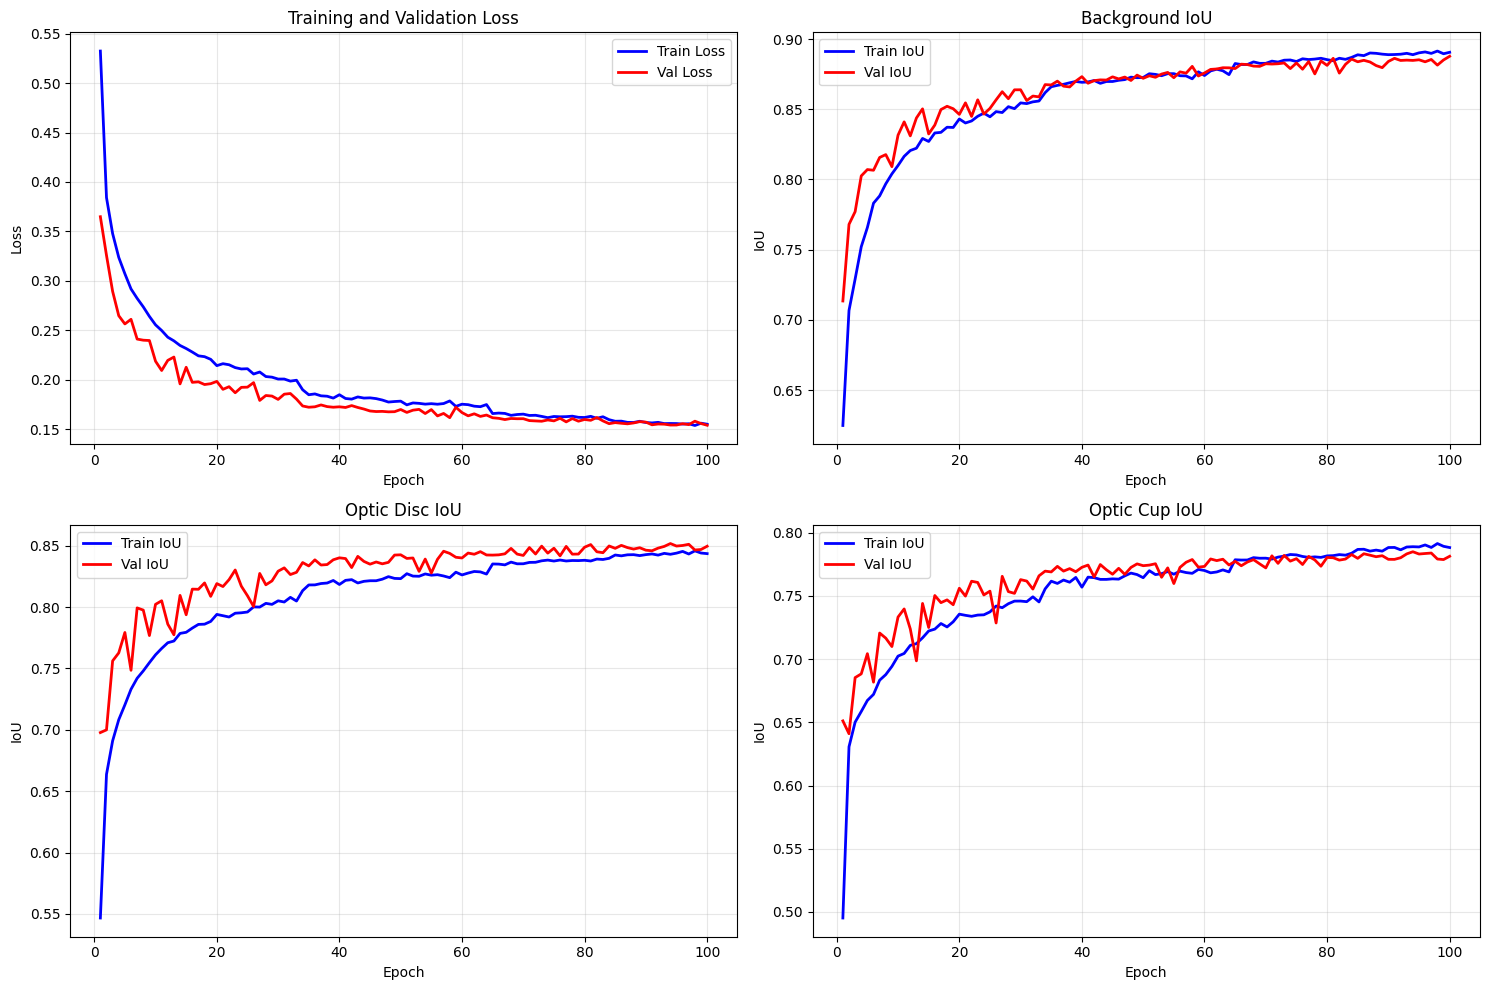

In [4]:
# Plot training history
fig = plot_training_history(
    history, 
    save_path=str(project_root / 'results' / 'training_history.png')
)
plt.show()


## 5. Print Final Metrics

In [5]:
print("\n" + "=" * 80)
print("FINAL TRAINING RESULTS")
print("=" * 80)

final_epoch = len(history['train_loss'])
print(f"\nTotal Epochs: {final_epoch}")

print("\nFinal Training Metrics:")
print(f"  Loss:        {history['train_loss'][-1]:.4f}")
print(f"  IoU (BG):    {history['train_iou_bg'][-1]:.4f}")
print(f"  IoU (Disc):  {history['train_iou_disc'][-1]:.4f}")
print(f"  IoU (Cup):   {history['train_iou_cup'][-1]:.4f}")

print("\nFinal Validation Metrics:")
print(f"  Loss:        {history['val_loss'][-1]:.4f}")
print(f"  IoU (BG):    {history['val_iou_bg'][-1]:.4f}")
print(f"  IoU (Disc):  {history['val_iou_disc'][-1]:.4f}")
print(f"  IoU (Cup):   {history['val_iou_cup'][-1]:.4f}")

print("\nBest Validation Loss:")
best_epoch = history['val_loss'].index(min(history['val_loss'])) + 1
best_val_loss = min(history['val_loss'])
print(f"  Epoch: {best_epoch}")
print(f"  Loss:  {best_val_loss:.4f}")

print("\n" + "=" * 80)



FINAL TRAINING RESULTS

Total Epochs: 100

Final Training Metrics:
  Loss:        0.1552
  IoU (BG):    0.8905
  IoU (Disc):  0.8436
  IoU (Cup):   0.7882

Final Validation Metrics:
  Loss:        0.1542
  IoU (BG):    0.8877
  IoU (Disc):  0.8496
  IoU (Cup):   0.7813

Best Validation Loss:
  Epoch: 100
  Loss:  0.1542



## 6. Save Training History

In [ ]:
import json

# Save history as JSON
results_dir = project_root / 'results'
results_dir.mkdir(exist_ok=True, parents=True)

history_path = results_dir / 'training_history.json'
with open(history_path, 'w') as f:
    json.dump(history, f, indent=2)

print(f"Training history saved to: {history_path}")


Training history saved to: /home/robolab/dev/CAP5410-roi-enhancer-odoc/results/training_history.json


: 